# LeetCode #195: Tenth Line

https://leetcode.com/problems/tenth-line/

## Comparison of Approaches
| Approach | Time | Space |
|---|---|---|
| sed -n '10p' ★ | O(n) | O(1) |
| awk 'NR==10' | O(n) | O(1) |
| head + tail | O(n) | O(1) |

## Understanding the Methods
### sed (Optimal Shell)
The command `sed -n '10p'` suppresses default output (`-n`) and prints only line 10 (`10p`). Simplest and most idiomatic.

### awk
`awk 'NR==10'` prints the line where the record number equals 10. Equally concise.

### head + tail
`head -n 10 file.txt | tail -n 1` gets the first 10 lines then takes the last one. Works but spawns two processes.

## Solutions

### C#

In [ ]:
// Shell Problem — Bash solution:
// sed -n '10p' file.txt
//
// Alternative: awk 'NR==10' file.txt
// Alternative: head -n 10 file.txt | tail -n 1

// C# equivalent:
using System;
using System.IO;
using System.Linq;

var lines = File.ReadAllLines("file.txt");
if (lines.Length >= 10) {
    Console.WriteLine(lines[9]);
}

### Python

In [ ]:
def tenth_line(filename: str) -> str | None:
    with open(filename) as f:
        for i, line in enumerate(f, 1):
            if i == 10:
                return line.strip()
    return None

# Usage:
# result = tenth_line('file.txt')
# if result is not None:
#     print(result)

### Go

In [ ]:
package main

import (
    "bufio"
    "fmt"
    "os"
)

func main() {
    file, _ := os.Open("file.txt")
    defer file.Close()
    scanner := bufio.NewScanner(file)
    lineNum := 0
    for scanner.Scan() {
        lineNum++
        if lineNum == 10 {
            fmt.Println(scanner.Text())
            return
        }
    }
}

### Rust

In [ ]:
use std::io::{self, BufRead};

fn main() {
    let stdin = io::stdin();
    if let Some(line) = stdin.lock().lines().nth(9) {
        println!("{}", line.unwrap());
    }
}

## Examples

**1. Common Case — File with 15 Lines**
**Input:** `file.txt` with 15 lines of text
`sed -n '10p'` reads sequentially, suppressing output (`-n`). At line 10, the `p` command prints it. Lines 1–9 and 11–15 are silently skipped.
*Why tricky:* Baseline — sed scans $O(n)$ lines but outputs only one. Early exit with `q` is possible but not required.

**2. Slightly Complex — Exactly 10 Lines**
**Input:** `file.txt` with exactly 10 lines
Line 10 is the last line. sed reaches it just before EOF and prints it. The boundary between "has 10th line" and "doesn't" is exactly this case.
*Why tricky:* Boundary condition — the 10th line exists but is the very last. Tests off-by-one between $n \geq 10$ and $n < 10$.

**3. Edge Case: Time Factor — Huge File ($10^7$ lines)**
**Input:** `file.txt` with 10,000,000 lines
Naive `sed -n '10p'` reads all $10^7$ lines. Optimized: `sed -n '10{p;q}'` reads only 10 lines then quits. Speedup $= 10^7 / 10 = 10^6\times$.
*Why tricky:* Without `q`, sed scans the entire file needlessly. The early-exit optimization is $10^6\times$ faster — $O(1)$ vs $O(n)$.

**4. Edge Case: Space Factor — 100 MB Single Line**
**Input:** `file.txt` with 10 lines, line 10 = 100 MB of text (no newlines within it)
sed buffers the current line in its pattern space. A 100 MB line requires 100 MB of memory. Space $= O(L)$ where $L$ = max line length.
*Why tricky:* sed's pattern space must hold the entire line. Extremely long lines stress the tool's memory limits.

**5. Almost-Impossible but Plausible — File with < 10 Lines**
**Input:** `file.txt` with 9 lines (or 0 lines, or 1 line)
No 10th line exists. sed never matches NR $= 10$, so `p` never fires. Output is empty — not an error. Boundary: 9 lines → empty, 10 lines → content.
*Why tricky:* The "no match" path must produce empty output, not an error. Tests the $n < 10$ boundary cleanly.

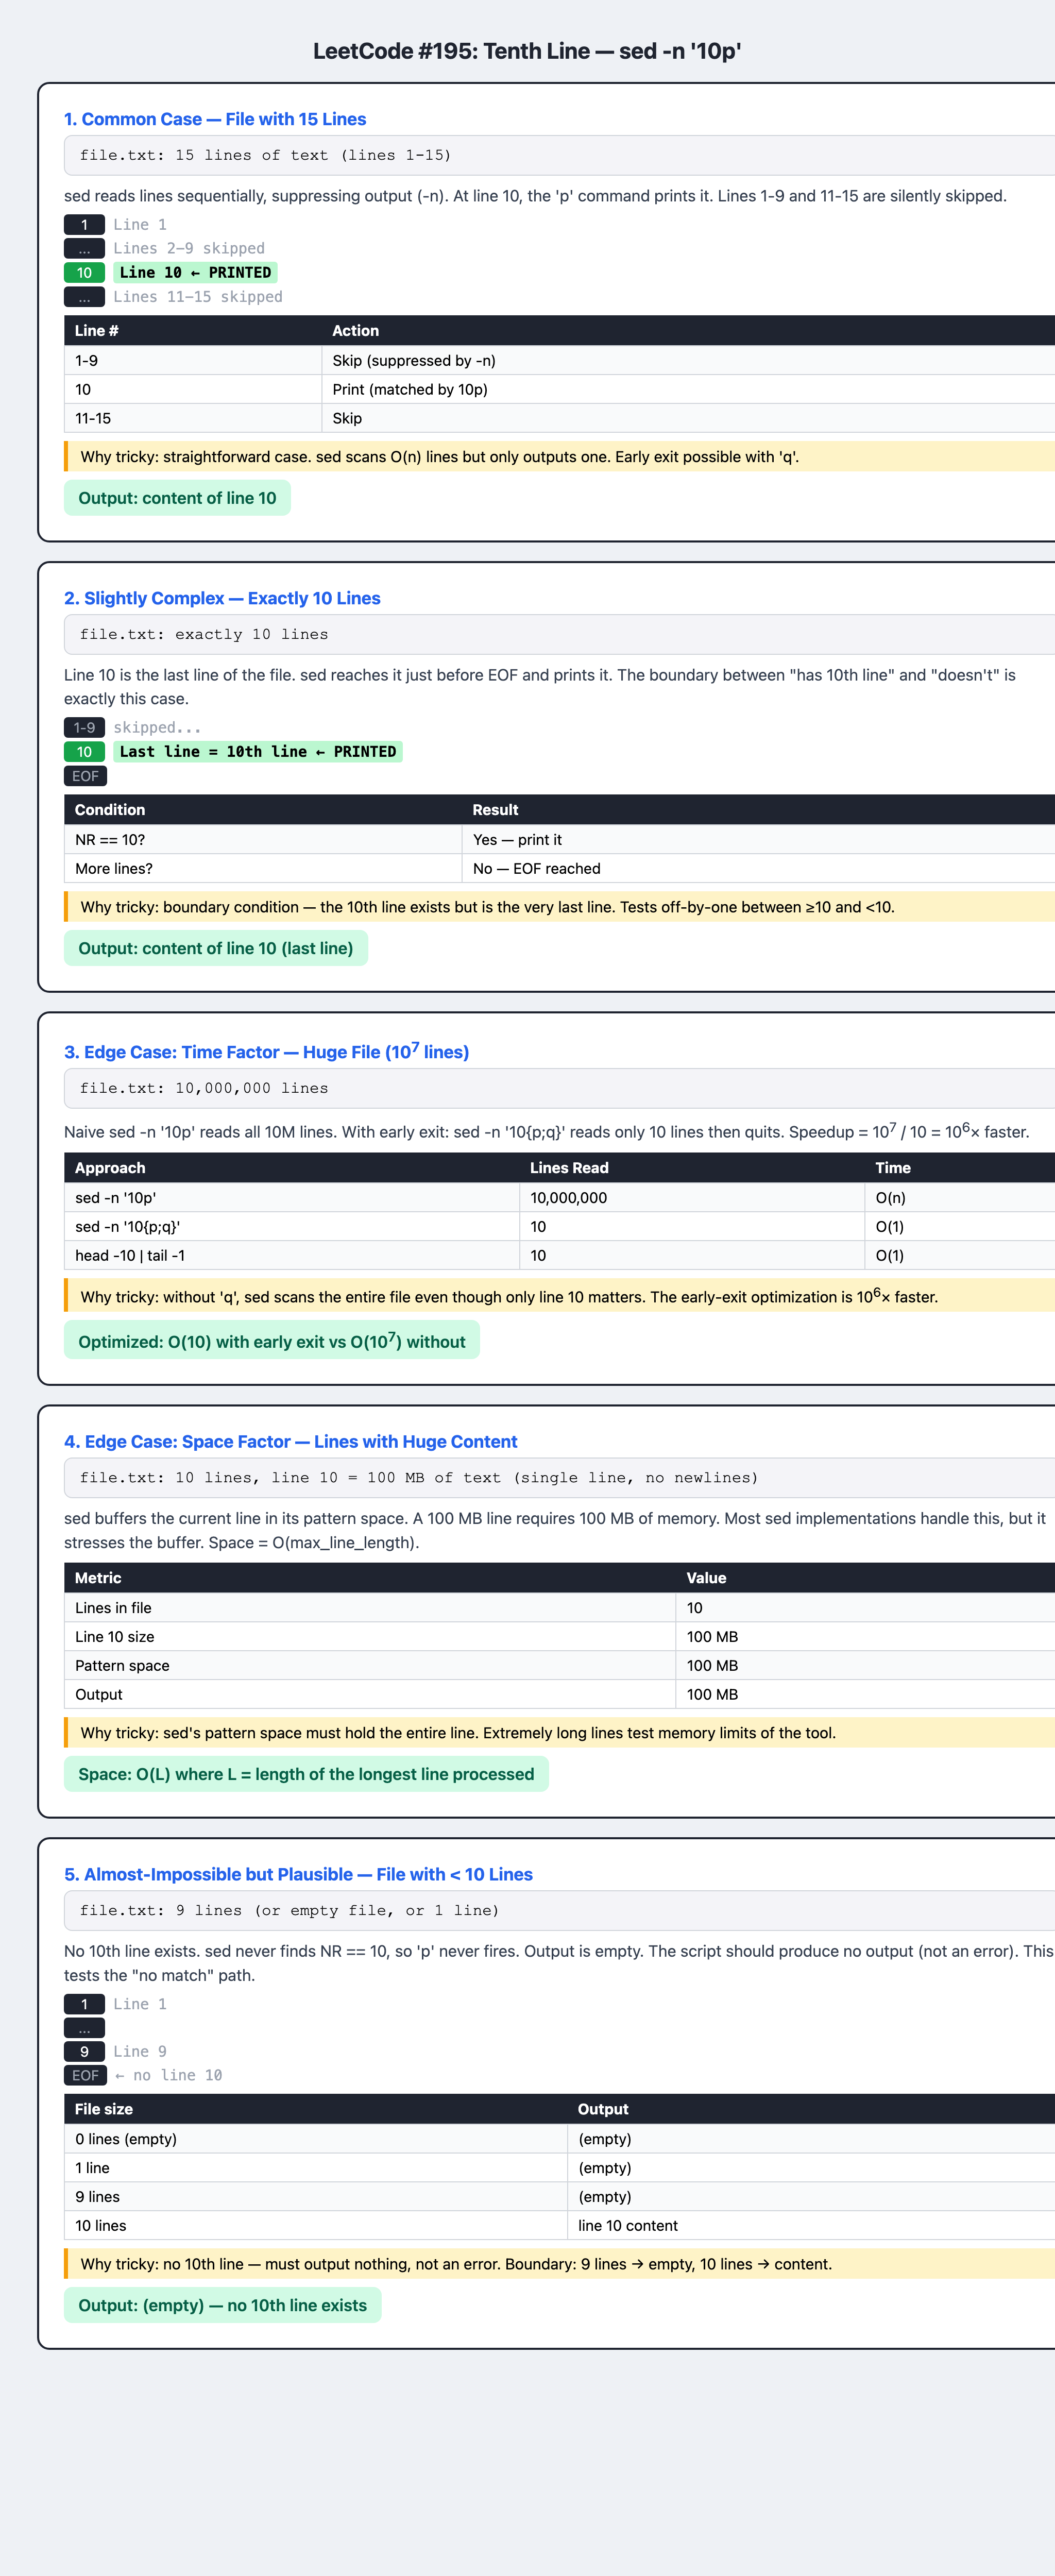